In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
)

Downloading bucket files: 89112643 / 89112643 complete

Downloading bytes: 89112643 / 89112643 complete

In [2]:
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
)
writer.dump()

Writing counts: 2 / 2 complete

In [4]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10
)
ds

Computing RNA initialization statistics: 1 / 1 complete

DataStore has 5025 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'feature_type', 'genome', 
            'nCells', 'dropOuts'

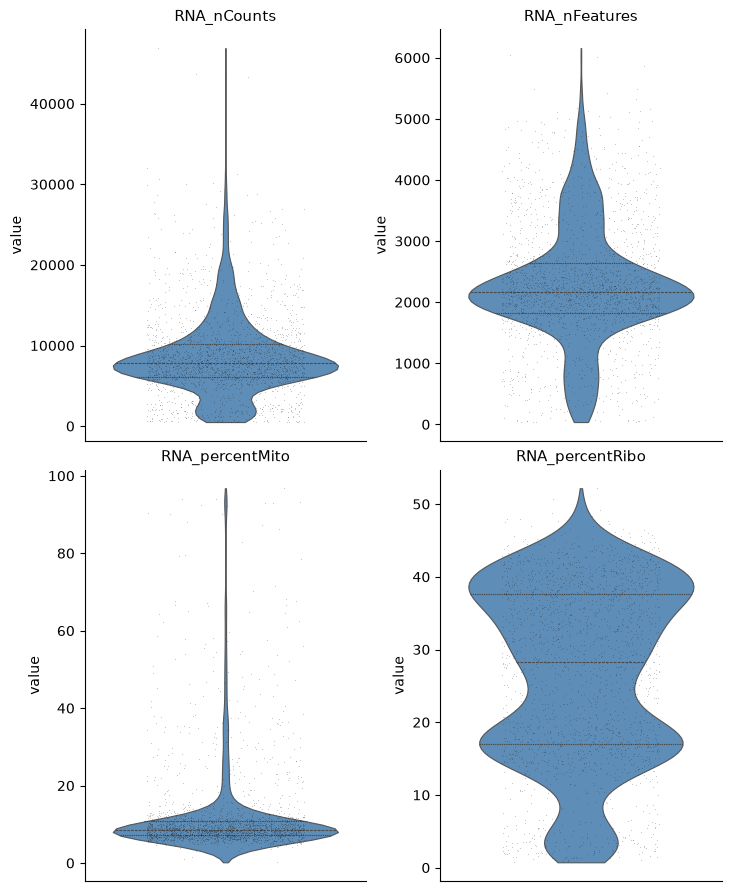

In [5]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

In [6]:
n_before = int(ds.cells.fetch_all('I').sum())
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0]
)
I = ds.cells.fetch_all('I')
print(f'Active cells before filter: {n_before}')
print(f'Active cells after filter: {int(I.sum())}')
print(f'Inactive cells (I=False): {int((~I).sum())}; total in store: {len(I)}')
ds.cells.to_pandas_dataframe(columns=['I'])['I'].value_counts()

Active cells before filter: 5025
Active cells after filter: 3940
Inactive cells (I=False): 1085; total in store: 5025


I
True     3940
False    1085
Name: count, dtype: int64

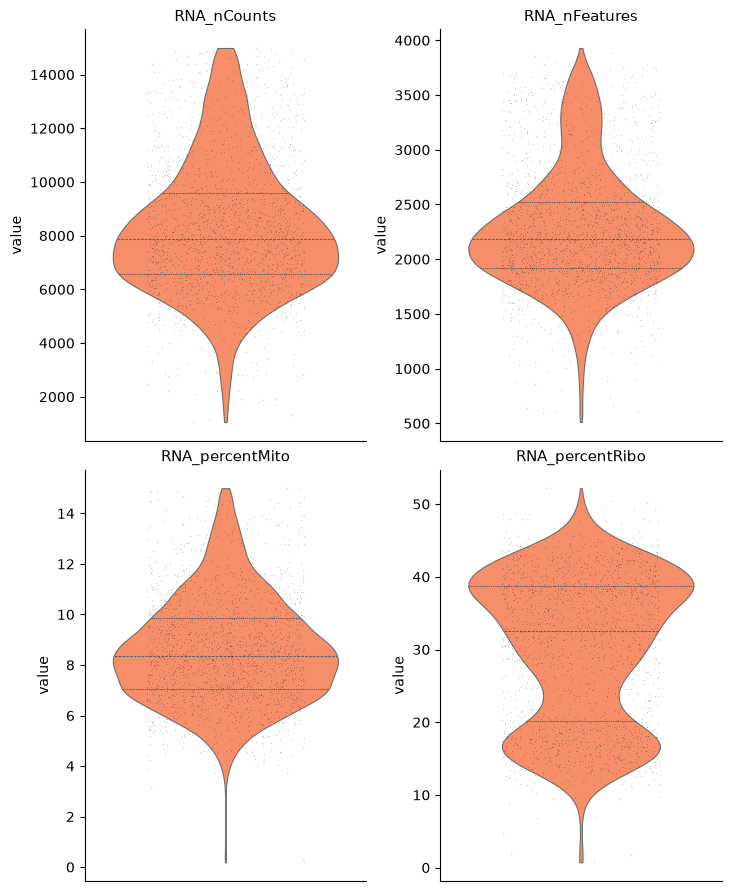

In [7]:
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)

Calculating feature statistics: 7 / 7 complete

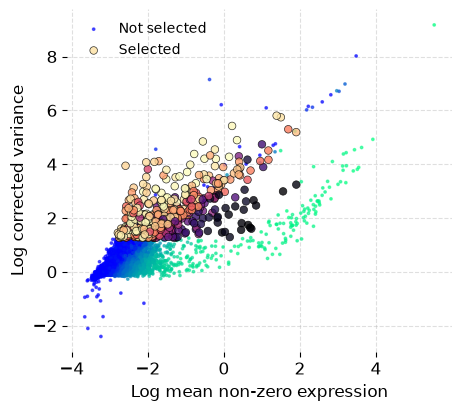

Selected genes: 498


In [8]:
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=True,
)
print('Selected genes:', int(ds.RNA.feats.fetch_all('I__hvgs').sum()))

In [9]:
normalized = ds.run_normalization(feat_key='hvgs')
opts = ds.inspect_artifact(normalized).execution_options or {}
print('Size factor (ds.RNA.sf):', ds.RNA.sf)
print('cell_key:', opts.get('cell_key'), 'feat_key:', opts.get('feat_key'))

Writing data: 1 / 1 complete

Size factor (ds.RNA.sf): 1000
cell_key: I feat_key: hvgs


Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

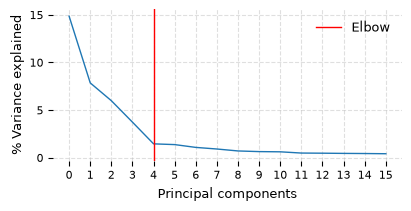

ArtifactRef(assay='RNA', kind='reduction', artifact_id='822b28a33db9...')

In [10]:
ds.run_pca(dims=15, show_elbow_plot=True)

In [11]:
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()

graph = ds.load_graph()
degrees = graph.getnnz(axis=1)
print(graph.shape, graph.nnz)
print(
    'Degree min / median / max:',
    int(degrees.min()),
    int(np.median(degrees)),
    int(degrees.max()),
)

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

(3940, 3940) 43340
Degree min / median / max: 11 11 11


In [12]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP: 250 / 250 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='928dea7911fc...')

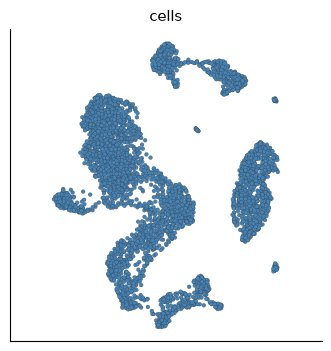

In [13]:
ds.plots.embedding(layout_key='RNA_UMAP')

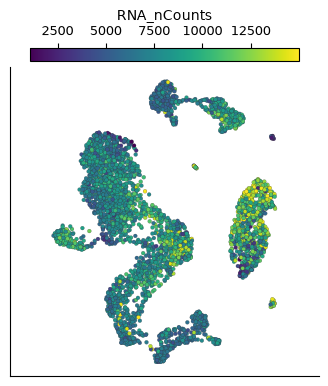

In [14]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
)

In [15]:
ds.run_leiden_clustering(resolution=0.5)
ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)['RNA_leiden_cluster'].value_counts().sort_index()

RNA_leiden_cluster
1     1261
2      699
3      670
4      318
5      299
6      252
7      246
8      143
9       25
10      15
11      12
Name: count, dtype: int64

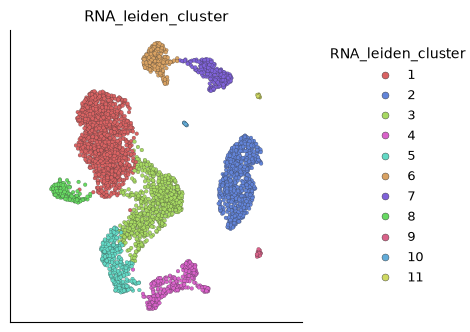

In [16]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [17]:
paris = ds.run_paris_clustering()
ds.cells.to_pandas_dataframe(
    columns=[paris.label_key],
    key='I'
)[paris.label_key].value_counts().sort_index()

RNA_paris_cluster
1      722
2      248
3     1231
4      317
5      296
6      112
7      252
8      566
9      169
10      15
11      12
Name: count, dtype: int64

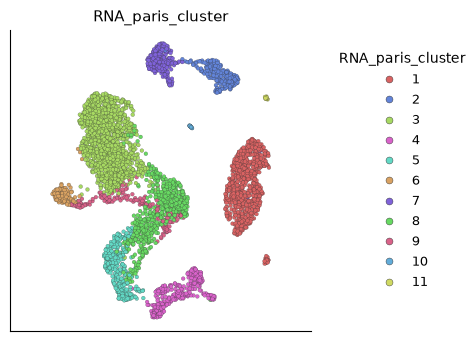

In [18]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris.label_key,
)

In [19]:
pd.crosstab(
    pd.Series(ds.cells.fetch('RNA_leiden_cluster', key='I'), name='Leiden'),
    pd.Series(ds.cells.fetch(paris.label_key, key='I'), name='Paris'),
)

Paris,1,2,3,4,5,6,7,8,9,10,11
Leiden,,,,,,,,,,,
1,0,0,1198,0,0,3,0,12,48,0,0
2,697,0,0,0,0,0,2,0,0,0,0
3,0,0,29,0,19,0,0,532,90,0,0
4,0,0,0,316,1,0,0,1,0,0,0
5,0,0,1,1,276,0,0,21,0,0,0
6,0,2,0,0,0,0,250,0,0,0,0
7,0,246,0,0,0,0,0,0,0,0,0
8,0,0,3,0,0,109,0,0,31,0,0
9,25,0,0,0,0,0,0,0,0,0,0


In [20]:
ds.run_marker_search(group_key='RNA_leiden_cluster')

Finding markers: 1 / 1 complete

Aggregating marker values per group: 1 / 1 complete

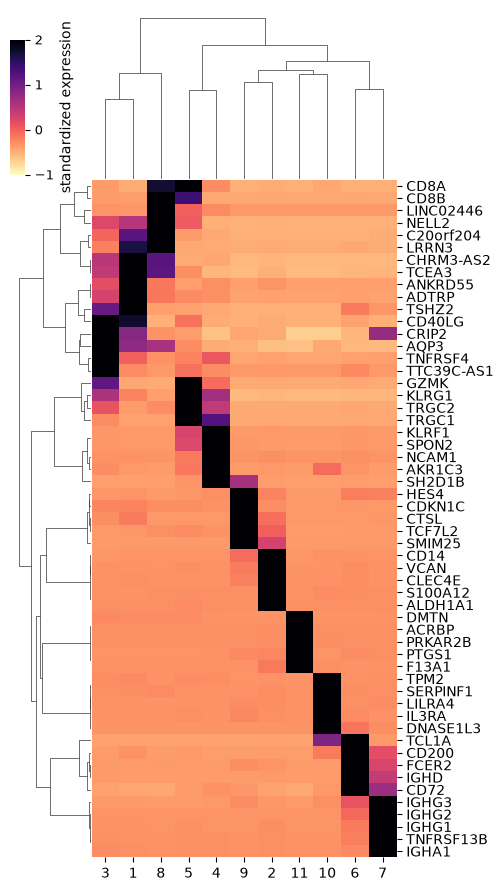

In [21]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9)
)

In [22]:
df = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
df.head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,ADTRP,10307,0.65392,0.04279,0.00279,0.23870,0.02202,15.33521,2.476793e-109,0.60948,1.832955e-107
1,1,TSHZ2,29849,0.57190,0.07198,0.01066,0.32593,0.04927,6.75262,4.094205e-123,0.63942,3.677832e-121
2,1,ANKRD55,8924,0.56296,0.02191,0.00114,0.14750,0.00971,19.15811,4.492931e-72,0.56922,1.649679e-70
3,1,CHRM3-AS2,3027,0.50922,0.06777,0.00821,0.38303,0.05786,8.24963,6.665595e-152,0.66602,8.278669e-150
4,1,TCEA3,487,0.50281,0.03187,0.00409,0.21015,0.03285,7.79982,7.034657e-76,0.59004,2.737766e-74


In [23]:
markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)
panel = markers[markers['feature_name'].isin(['CD14', 'MS4A1', 'CD3D'])]
panel.sort_values(
    ['feature_name', 'score'], ascending=[True, False]
).groupby('feature_name', sort=False).head(2)

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
14285,2,CD14,9635,0.91583,0.93084,0.00246,0.96996,0.01759,378.60714,0.000000e+00,0.98424,0.000000e+00
123521,9,CD14,9635,0.04760,0.05383,0.16789,0.32000,0.18570,0.32061,2.872799e-01,0.54189,6.293281e-01
57188,5,CD3D,18652,0.29026,0.82708,0.34295,0.98328,0.59599,2.41163,7.364460e-77,0.81370,2.697092e-74
212,1,CD3D,18652,0.19954,0.54301,0.30282,0.96907,0.46361,1.79320,3.397093e-126,0.72933,3.150693e-124
71444,6,MS4A1,17795,0.48438,1.11944,0.07807,0.98810,0.09517,14.33871,0.000000e+00,0.96088,0.000000e+00
85714,7,MS4A1,17795,0.48385,1.10432,0.08077,0.99593,0.09610,13.67263,0.000000e+00,0.96357,0.000000e+00


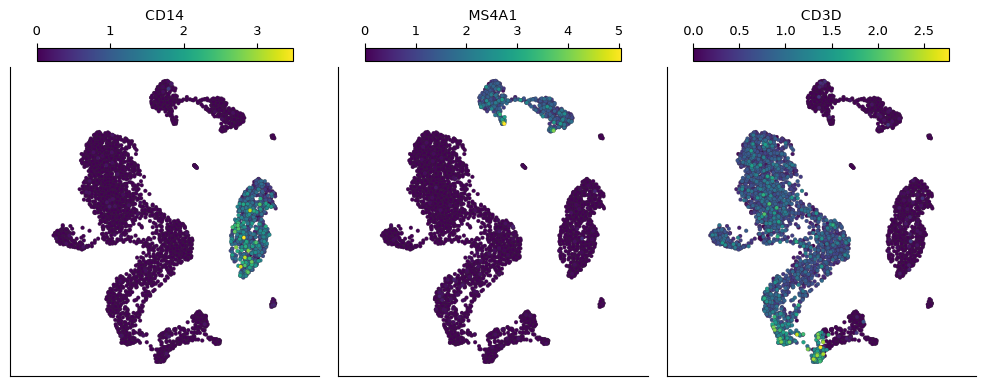

In [24]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)